In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dataset-2/TRIB Crack Dataset/2. Agumented images_size of 256x256 pixels/1. With cracks/2. Rotation/623.jpg
/kaggle/input/dataset-2/TRIB Crack Dataset/2. Agumented images_size of 256x256 pixels/1. With cracks/2. Rotation/764.jpg
/kaggle/input/dataset-2/TRIB Crack Dataset/2. Agumented images_size of 256x256 pixels/1. With cracks/2. Rotation/771.jpg
/kaggle/input/dataset-2/TRIB Crack Dataset/2. Agumented images_size of 256x256 pixels/1. With cracks/2. Rotation/208.jpg
/kaggle/input/dataset-2/TRIB Crack Dataset/2. Agumented images_size of 256x256 pixels/1. With cracks/2. Rotation/473.jpg
/kaggle/input/dataset-2/TRIB Crack Dataset/2. Agumented images_size of 256x256 pixels/1. With cracks/2. Rotation/333.jpg
/kaggle/input/dataset-2/TRIB Crack Dataset/2. Agumented images_size of 256x256 pixels/1. With cracks/2. Rotation/537.jpg
/kaggle/input/dataset-2/TRIB Crack Dataset/2. Agumented images_size of 256x256 pixels/1. With cracks/2. Rotation/45.jpg
/kaggle/input/dataset-2/TRIB Crac

In [2]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam


2025-12-08 12:44:02.811432: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765197843.015611      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765197843.081521      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [3]:
pycrack_path = "/kaggle/input/dataset-1/Classification"
trib_path    = "/kaggle/input/dataset-2/TRIB Crack Dataset/3. Resized and augmented images"


In [4]:
#train and test
train_gen = ImageDataGenerator(rescale=1./255, validation_split=0.20)

train_ds = train_gen.flow_from_directory(
    pycrack_path, target_size=(224,224), batch_size=32,
    class_mode='categorical', subset="training"
)

test_ds = train_gen.flow_from_directory(
    pycrack_path, target_size=(224,224), batch_size=32,
    class_mode='categorical', subset="validation", shuffle=False
)

Found 456 images belonging to 2 classes.
Found 113 images belonging to 2 classes.


In [5]:
#VGG16 Best Model Training
vgg = VGG16(weights="imagenet", include_top=False, input_shape=(224,224,3))

for layer in vgg.layers:
    layer.trainable = False  

x = Flatten()(vgg.output)
x = Dense(256, activation='relu')(x)
output = Dense(train_ds.num_classes, activation='softmax')(x)

2025-12-08 12:44:20.565860: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
model = Model(inputs=vgg.input, outputs=output)
model.compile(optimizer=Adam(0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_ds, validation_data=test_ds, epochs=5)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 150s 10s/step - accuracy: 0.6771 - loss: 0.6414 - val_accuracy: 0.9912 - val_loss: 0.0871
Epoch 2/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 203s 10s/step - accuracy: 0.9628 - loss: 0.1268 - val_accuracy: 1.0000 - val_loss: 0.0356
Epoch 3/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 198s 10s/step - accuracy: 0.9827 - loss: 0.0649 - val_accuracy: 1.0000 - val_loss: 0.0257
Epoch 4/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 144s 10s/step - accuracy: 0.9962 - loss: 0.0459 - val_accuracy: 0.9912 - val_loss: 0.0278
Epoch 5/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 157s 11s/step - accuracy: 1.0000 - loss: 0.0234 - val_accuracy: 1.0000 - val_loss: 0.0212


In [7]:
loss, acc = model.evaluate(test_ds)
print("\n Test Accuracy:", acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 29s 7s/step - accuracy: 1.0000 - loss: 0.0208

 Test Accuracy: 1.0


In [8]:


model.save("best_vgg_model.keras")
print("\n Best model saved as: best_vgg_model.keras")



 Best model saved as: best_vgg_model.keras


In [9]:
# ---------------------------------------------
# FIXED GRAD-CAM FUNCTION (NO INDENTATION ERROR)
# ---------------------------------------------
def grad_cam(img, model, layer_name="block5_conv3"):

    img_tensor = np.expand_dims(img, axis=0)

    # Create model that returns conv-layer + predictions
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    # Compute gradients
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    # Apply weights
    for i in range(pooled_grads.shape[-1]):
        conv_outputs[:, :, i] *= pooled_grads[i]

    # Create heatmap
    heatmap = np.mean(conv_outputs, axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= (heatmap.max() + 1e-10)

    return heatmap


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


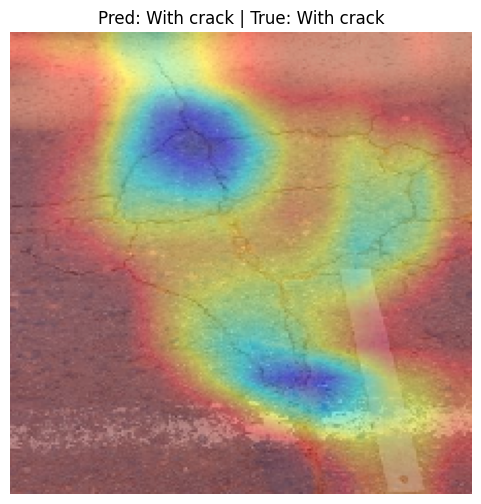

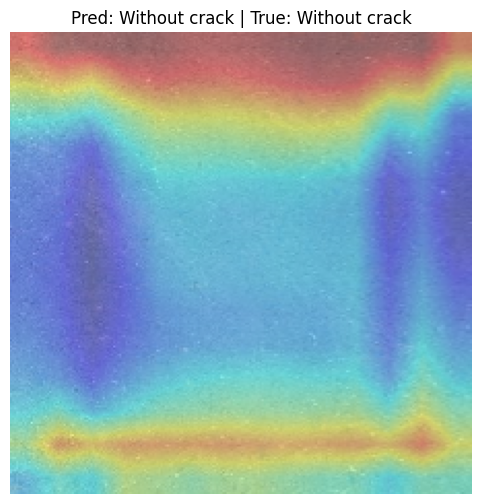

In [10]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ---------- fixed grad_cam function ----------
def grad_cam(img, model, layer_name="block5_conv3"):
    """
    img : single image array (H,W,C) with pixel range [0,1] or [0,255].
    model: keras model
    returns: heatmap numpy array (H,W) values in [0,1]
    """
    # ensure float32 and batch dimension, and scale to model's input range if needed
    img_tensor = tf.convert_to_tensor(np.expand_dims(img.astype(np.float32), axis=0))

    # Build grad model that outputs conv layer + predictions
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    # gradients of the target class wrt conv layer outputs
    grads = tape.gradient(loss, conv_outputs)            # shape (1, H, W, C)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2)) # shape (C,)

    # weighted combination of forward activation maps
    conv_outputs = conv_outputs[0]                       # shape (H, W, C)
    # elementwise multiply then sum over channels -> shape (H,W)
    weighted = tf.multiply(conv_outputs, pooled_grads)  # broadcasting (H,W,C) * (C,)
    heatmap = tf.reduce_sum(weighted, axis=-1)

    # relu + normalize
    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.reduce_max(heatmap)
    heatmap = heatmap / (max_val + 1e-10)

    return heatmap.numpy()

# ---------- visualization loop (fixed) ----------
shown = []
class_names = list(test_ds.class_indices.keys())

# test_ds yields batches of (images, labels) where images are in the same preprocessing you used for training
for batch_img, batch_lbl in test_ds:
    for i in range(len(batch_img)):
        img = batch_img[i]                       # this is typically float32 in [0,1]
        true = np.argmax(batch_lbl[i])
        # get prediction (use model(tf.expand_dims(...)) to avoid Keras input-structure warning)
        pred_logits = model(tf.expand_dims(img, 0), training=False).numpy()[0]
        pred = np.argmax(pred_logits)

        if pred not in shown:
            # compute heatmap
            heat = grad_cam(img, model)
            heat = cv2.resize(heat, (224, 224))
            heat = np.uint8(255 * heat)
            heat = cv2.applyColorMap(heat, cv2.COLORMAP_JET)

            # prepare original image for overlay
            # if img is normalized [0,1], convert to uint8
            if img.max() <= 1.0:
                orig = np.uint8(img * 255)
            else:
                orig = np.uint8(img)

            # ensure shapes: (H,W,C)
            if orig.shape[:2] != (224, 224):
                orig = cv2.resize(orig, (224, 224))

            overlay = cv2.addWeighted(orig, 0.6, heat, 0.4, 0)

            plt.figure(figsize=(6,6))
            plt.title(f"Pred: {class_names[pred]} | True: {class_names[true]}")
            plt.imshow(overlay[..., ::-1] if overlay.shape[2]==3 and False else overlay)  # show as-is (RGB assumed)
            plt.axis("off")
            plt.show()

            shown.append(pred)

    # stop once we've shown all classes
    if len(shown) == len(class_names):
        break


In [11]:
#Generalizability Testing
train_trib = ImageDataGenerator(rescale=1./255).flow_from_directory(
    trib_path, target_size=(224,224), batch_size=32, shuffle=True
)

test_trib = ImageDataGenerator(rescale=1./255).flow_from_directory(
    trib_path, target_size=(224,224), batch_size=32, shuffle=False
)

Found 11178 images belonging to 2 classes.
Found 11178 images belonging to 2 classes.


In [12]:
model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_trib, epochs=3)


Epoch 1/3
350/350 ━━━━━━━━━━━━━━━━━━━━ 2886s 8s/step - accuracy: 0.7114 - loss: 0.7296
Epoch 2/3
350/350 ━━━━━━━━━━━━━━━━━━━━ 2894s 8s/step - accuracy: 0.7845 - loss: 0.4626
Epoch 3/3
350/350 ━━━━━━━━━━━━━━━━━━━━ 2900s 8s/step - accuracy: 0.8135 - loss: 0.4134


In [13]:
loss, acc = model.evaluate(test_trib)
print("\n TRIB Dataset Test Accuracy:", acc)

350/350 ━━━━━━━━━━━━━━━━━━━━ 2935s 8s/step - accuracy: 0.8383 - loss: 0.3598

 TRIB Dataset Test Accuracy: 0.8387010097503662


In [14]:
model.save("best_vgg_model_TRIB.keras")
print("\n Retrained model saved as: best_vgg_model_TRIB.keras")


 Retrained model saved as: best_vgg_model_TRIB.keras


In [15]:
#Performance Comparison
print(" Final Comparison Result")
print(" Original Py-CrackDB Accuracy:", max(history.history['val_accuracy']))
print(" TRIB Retrained Accuracy:", acc)

 Final Comparison Result
 Original Py-CrackDB Accuracy: 1.0
 TRIB Retrained Accuracy: 0.8387010097503662
